<a href="https://colab.research.google.com/github/chandraniraychowdhury5/DS/blob/main/Wind_Energy_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [61]:
df = pd.read_csv('/content/drive/MyDrive/datasetAndProgram/Location1.csv')

Data cleaning


In [62]:
print(df.isnull().sum())
df.dropna(inplace = True)
print(df.duplicated().sum())
df.drop_duplicates(inplace = True)


Time                   0
temperature_2m         0
relativehumidity_2m    0
dewpoint_2m            0
windspeed_10m          0
windspeed_100m         0
winddirection_10m      0
winddirection_100m     0
windgusts_10m          0
Power                  0
dtype: int64
0


In [63]:
print(df.head())
print(df.info())
print(df.columns)

                  Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0  2017-01-02 00:00:00            28.5                   85         24.5   
1  2017-01-02 01:00:00            28.4                   86         24.7   
2  2017-01-02 02:00:00            26.8                   91         24.5   
3  2017-01-02 03:00:00            27.4                   88         24.3   
4  2017-01-02 04:00:00            27.3                   88         24.1   

   windspeed_10m  windspeed_100m  winddirection_10m  winddirection_100m  \
0           1.44            1.26                146                 162   
1           2.06            3.99                151                 158   
2           1.30            2.78                148                 150   
3           1.30            2.69                 58                 105   
4           2.47            4.43                 58                  84   

   windgusts_10m   Power  
0            1.4  0.1635  
1            4.4  0.1424  
2          

# **Descriptive Statistics**

In [64]:

print(df.describe())
print("*" * 100)
print("Range", df.max(numeric_only=True) - df.min(numeric_only= True))
print("*" * 100)
print("variance: ", df.var(numeric_only=True))
print("*" * 100)
print("IQR: ", df.quantile(0.75, numeric_only = True) - df.quantile(0.25, numeric_only = True))
print("*" * 100)
print("Skewness:", df.skew(numeric_only = True))
print("*" * 100)
print("Kurtosis:", df.kurt(numeric_only = True))
print("*" * 100)
print("Correlation: ")
print(df.corr(numeric_only = True))




       temperature_2m  relativehumidity_2m   dewpoint_2m  windspeed_10m  \
count    43800.000000         43800.000000  43800.000000   43800.000000   
mean        47.862911            72.288744     38.569308       3.591147   
std         19.453691            16.852287     18.772110       1.649318   
min        -14.400000            18.000000    -17.100000       0.000000   
25%         32.100000            60.000000     24.300000       2.410000   
50%         47.300000            74.000000     38.100000       3.300000   
75%         64.500000            86.000000     54.700000       4.590000   
max         94.100000           100.000000     76.300000      13.450000   

       windspeed_100m  winddirection_10m  winddirection_100m  windgusts_10m  \
count    43800.000000       43800.000000        43800.000000   43800.000000   
mean         6.284431         203.637329          203.343676       7.771795   
std          2.685216          96.371262           97.959852       3.569147   
min     

# **Plots**

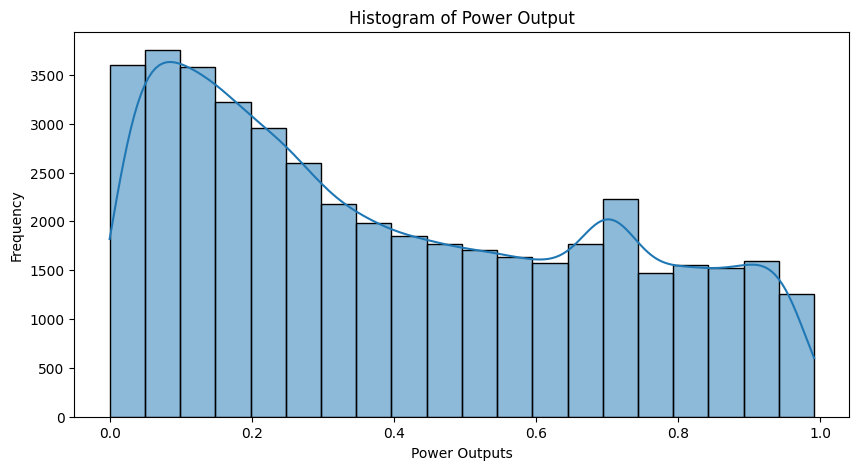

In [65]:
#histogram of power output
plt.figure(figsize = (10, 5))
sns.histplot(df['Power'], bins = 20, kde = True)
plt.xlabel("Power Outputs")
plt.ylabel("Frequency")
plt.title("Histogram of Power Output")
plt.show()


#A right-skewed wind turbine power output means
#the turbine spends most of its time generating low-to-moderate power, with infrequent spikes in high energy production.
#A highly right-skewed output typically occurs when a site experiences more gentle-to-moderate winds than strong gales,
# and the turbine spends significant time idling due to wind speeds falling below the cut-in limit.

KDE Plot

Kernel Density Estimation (KDE) is a non-parametric statistical method used to estimate the underlying probability density function (PDF) of a random variable. Unlike histograms, which use rigid, discrete bins, KDE places a smooth "kernel" (like a bell curve) over every individual data point and sums them to create a continuous curve

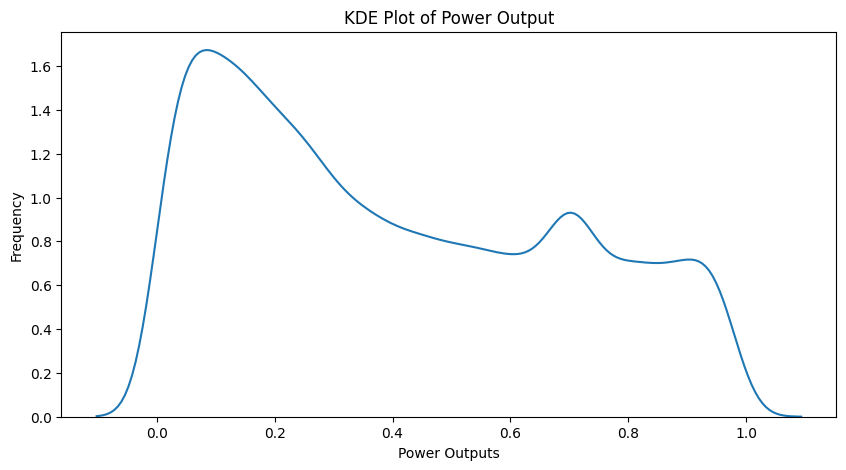

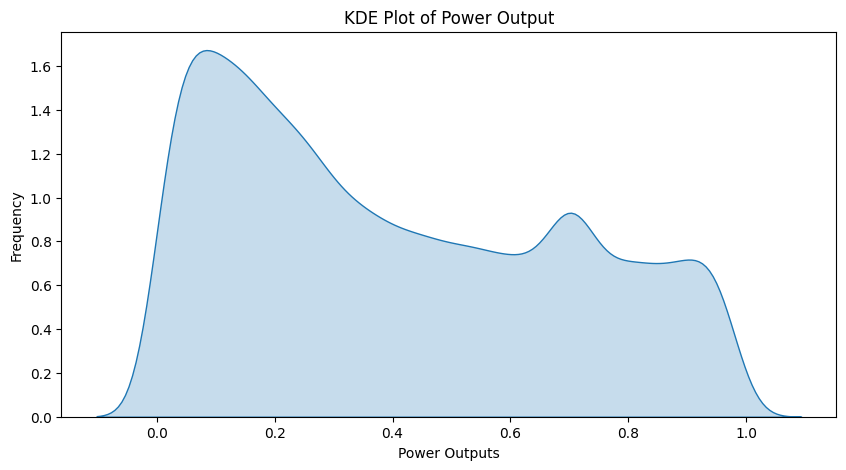

In [66]:
plt.figure(figsize = (10, 5))
sns.kdeplot(df['Power'], fill = False)
plt.xlabel("Power Outputs")
plt.ylabel("Frequency")
plt.title("KDE Plot of Power Output")
plt.show()

plt.figure(figsize = (10, 5))
sns.kdeplot(df['Power'], fill = True)
plt.xlabel("Power Outputs")
plt.ylabel("Frequency")
plt.title("KDE Plot of Power Output")
plt.show()


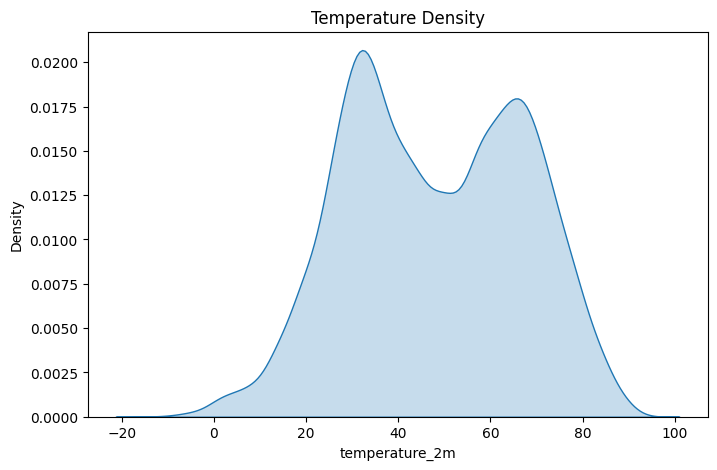

In [67]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['temperature_2m'], fill=True)
plt.title('Temperature Density')
plt.show()

#A bimodal distribution in temperature means exhibits two distinct peaks (or modes) in a probability curve,
#revealing that a dataset contains two prevalent,
#underlying regimes or subgroups rather than a single average.

BoxPlot

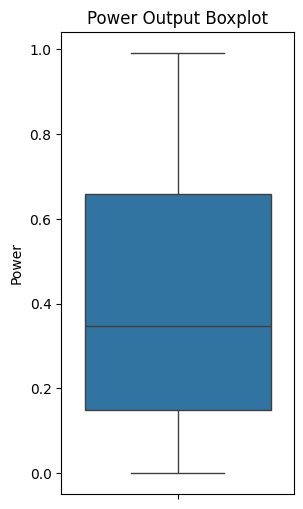

minimum power output  0.0
Q1, Q3, IQR:  0.1489 0.6596 0.5106999999999999
lower_bound, upper_bound:  -0.6171499999999999 1.4256499999999999
maximum power output:  0.9913
number of outliers:  0


In [68]:
plt.figure(figsize=(3,6))
sns.boxplot(df['Power'])
plt.title('Power Output Boxplot')
plt.show()

print("minimum power output ", df['Power'].min())
Q1 = df['Power'].quantile(0.25)
Q3 = df['Power'].quantile(0.75)
IQR = Q3 - Q1
print("Q1, Q3, IQR: ", Q1, Q3, IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("lower_bound, upper_bound: ", lower_bound, upper_bound)
outliers = df[(df["Power"] < lower_bound) | (df["Power"] > upper_bound)]
print("maximum power output: ", df['Power'].max())
print("number of outliers: ", len(outliers))


Violin Plot

A violin plot of wind turbine power illustrates the probability density of power output across varying wind conditions. It combines a density trace (rotated to look like a violin) with an embedded box plot, showing the median, interquartile range, and data spread.

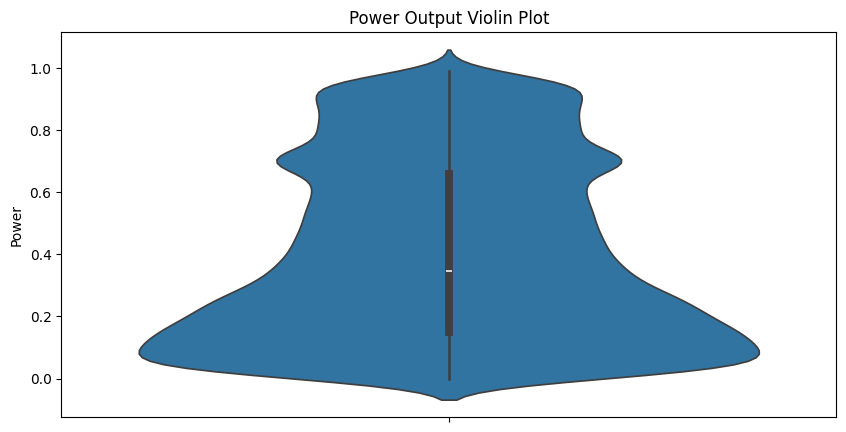

In [69]:
plt.figure(figsize=(10,5))
sns.violinplot(y=df['Power'])
plt.title('Power Output Violin Plot')
plt.show()

#The violin plot depicts the dominant low-power operation -- meaning the turbine spends most of its operational time
#generating minimal energy.

Pair plot -- depicts relationship among multiple variables

<Figure size 1000x500 with 0 Axes>

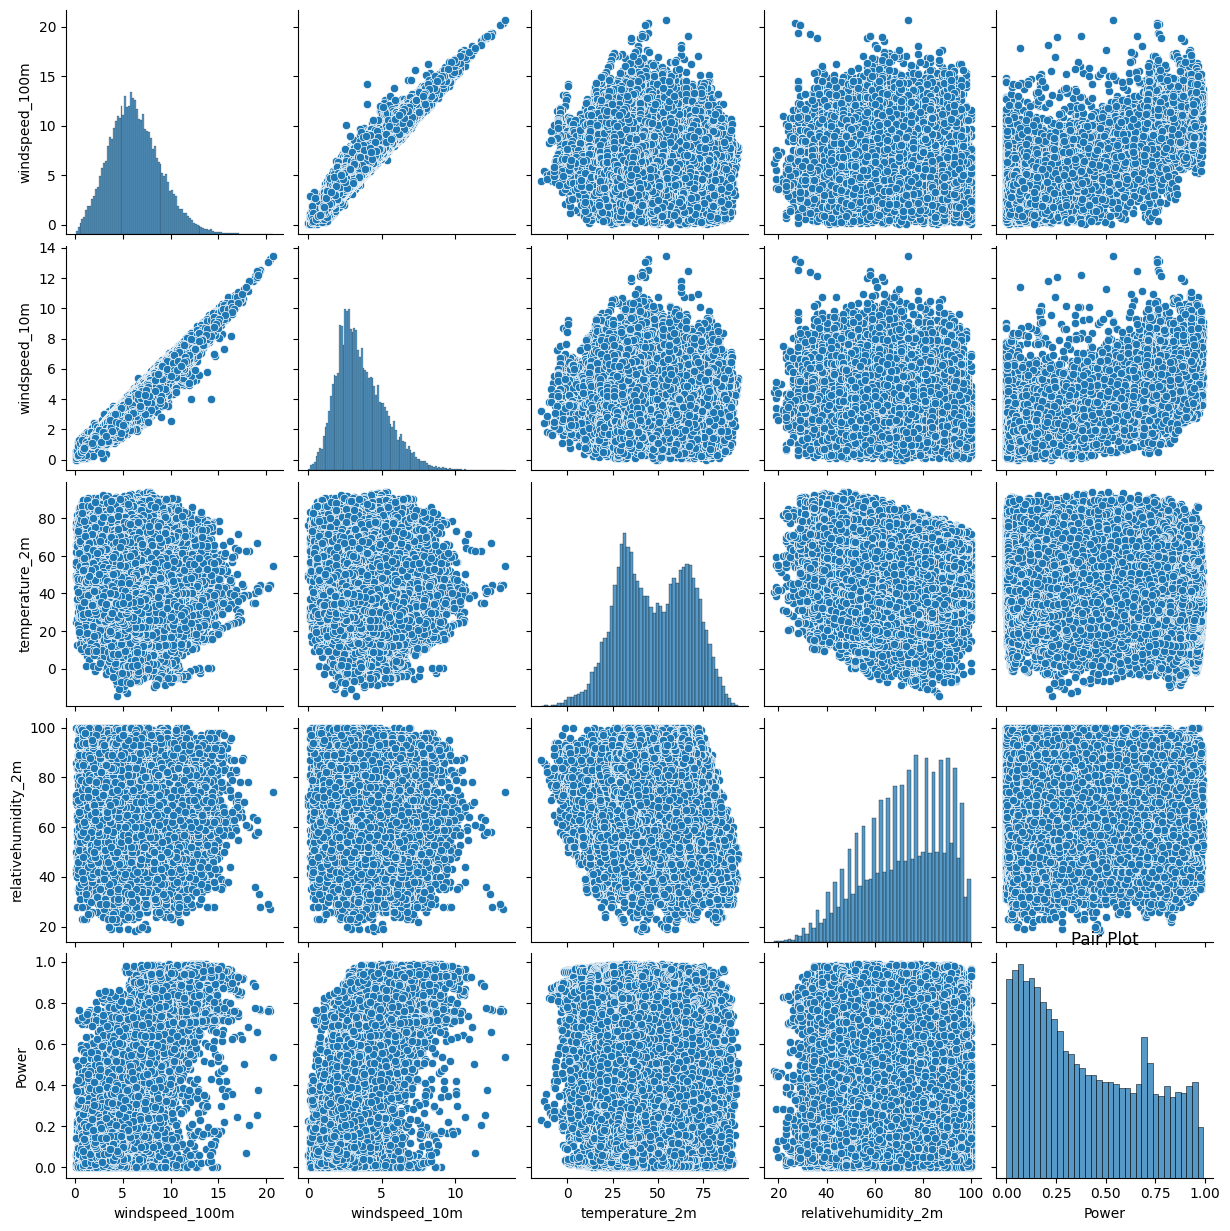

In [70]:
plt.figure(figsize=(10,5))
sns.pairplot(
    df[
        ['windspeed_100m',
         'windspeed_10m',
         'temperature_2m',
         'relativehumidity_2m',
         'Power']
    ]
)
plt.title('Pair Plot')
plt.show()


Heatmap

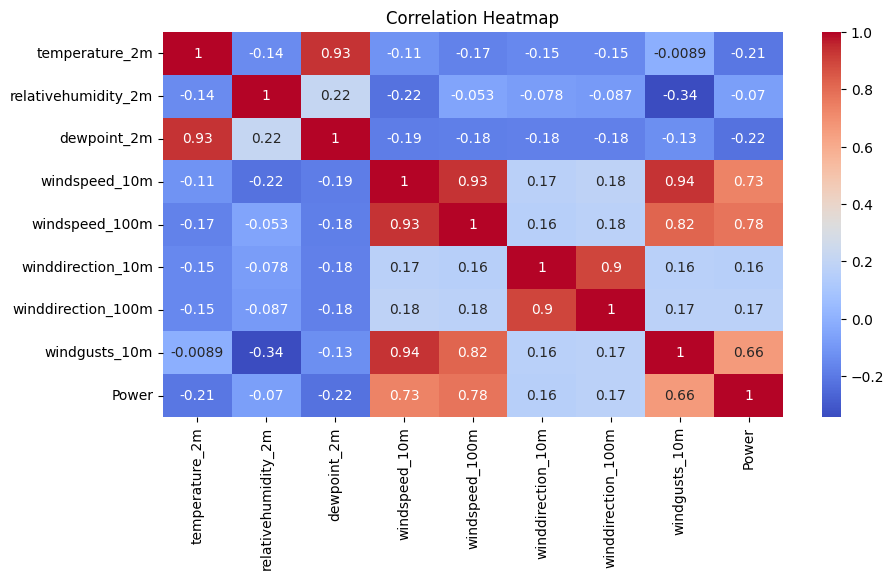

In [71]:
plt.figure(figsize = (10, 5))
cor = df.corr(numeric_only = True)
sns.heatmap(cor, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#power output mainly depends on wind speed and wind gusts as shown in Heatmap.
# windspeed_100m (0.78), windspeed_10m (0.73), and windgusts_10m (0.66) have a strong positive correlation with Power.
# dewpoint_24m (-0.22) and temperature_2m (-0.21) have a weak negative correlation with Power.